In [8]:
pip install pycaret

In [9]:
import pandas as pd

URL = "https://raw.githubusercontent.com/alexandrezamberlan/tias/main/3_predicao_previsao_codigos_exemplos/dados_predicao_modelos.csv"
df = pd.read_csv(URL)

print("--- Primeiras 5 linhas ---")
display(df.head())

print("\n--- Últimas 5 linhas ---")
display(df.tail())

--- Primeiras 5 linhas ---


,Idade,Renda_Anual_K,Score_Credito,Pontuacao_Engajamento,Compro_Produto
0,56,141.8,534,7.1,0
1,46,37.9,308,8.1,0
2,32,64.3,373,5.5,0
3,60,34.8,791,1.8,0
4,25,140.2,552,5.8,0



--- Últimas 5 linhas ---


,Idade,Renda_Anual_K,Score_Credito,Pontuacao_Engajamento,Compro_Produto
245,24,84.3,836,8.5,0
246,58,27.5,444,4.6,0
247,50,91.4,824,7.0,1
248,57,77.4,511,2.8,1
249,56,135.4,324,3.6,0


### Base de dados já limpa, todas features já são numéricas, não precisa de LabelEnconder

In [10]:
FEATURES = [
    "Idade",
    "Renda_Anual_K",
    "Score_Credito",
    "Pontuacao_Engajamento"
]

TARGET = "Compro_Produto"

print(df[TARGET].value_counts())

Compro_Produto
0    151
1     99
Name: count, dtype: int64


151 nao compraram
99 compraram

In [11]:
import pycaret
from pycaret.classification import setup, models, compare_models, pull
# Traz as ferramentas do PyCaret que vamos usar: setup, listagem de modelos,
# comparação de modelos e pull (pra "puxar" a tabela de resultados).

setup (
    data=df[FEATURES + [TARGET]],  #base de dados, só com as colunas de interesse
    target=TARGET,                # coluna da resposta para prever
    session_id=42,                #para dar sempre o mesmo resultado se rodar de novo
    train_size=0.8,               #80% treino 20% teste
    fold=5,                       # divide o conjunto de treinamento em 5 partes (folds) para validação cruzada. usa 4 folds para treinamento e 1 para validar em cada iteração.
    n_jobs=-1,                    #usa todos nucles do processador
    use_gpu=False,
    verbose=False,                #nao mostra a tabela de config que o setup imprime
    fix_imbalance=False,          # nao tenta corrigir/balancear as classes automaticamente (quando vazias)
    normalize=True,               #padroniza as escalas das colunas (importante para KNN, SVM ...)

)


# Treina e testa vários algoritmos diferentes de uma vez usando validação cruzada, e devolve a lista ordenada.
best_models = compare_models(
    sort="F1",                  # ordena o ranking dos modelos pela métrica F1 (do melhor pro pior)
    n_select=len(models()),     # pede pra retornar TODOS os modelos testados, não só o melhor
    turbo=False,                # desliga o modo rápido, que pularia alguns modelos mais pesados
)

leaderboard = pull() #salva a ultima tabela de resultados numa variavel

pd.set_option('display.max_rows', None)  # tira o limite de linhas que o pandas mostra
display(leaderboard)                     # exibe a tabela completa com todas as métricas de todos os modelos

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
mlp,MLP Classifier,0.7050,0.7311,0.5183,0.6694,0.5775,0.3576,0.3687,0.6940
gbc,Gradient Boosting Classifier,0.6850,0.7239,0.5458,0.6157,0.5760,0.3281,0.3313,0.0920
nb,Naive Bayes,0.6950,0.7142,0.5183,0.6487,0.5744,0.3405,0.3475,0.0420
knn,K Neighbors Classifier,0.6800,0.7392,0.5442,0.6073,0.5678,0.3165,0.3216,0.0840
lr,Logistic Regression,0.6950,0.7268,0.5058,0.6602,0.5673,0.3383,0.3495,1.9820
ridge,Ridge Classifier,0.6950,0.7267,0.5058,0.6602,0.5673,0.3383,0.3495,0.0440
lda,Linear Discriminant Analysis,0.6900,0.7267,0.5058,0.6474,0.5624,0.3285,0.3383,0.0280
et,Extra Trees Classifier,0.6950,0.7486,0.5200,0.6355,0.5622,0.3378,0.3447,0.1220
dt,Decision Tree Classifier,0.6300,0.6235,0.5950,0.5370,0.5621,0.2440,0.2463,0.0420
gpc,Gaussian Process Classifier,0.7050,0.7240,0.4808,0.6955,0.5588,0.3493,0.3686,0.1200


Processing:   0%|          | 0/94 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pycaret/internal/pycaret_experiment/supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
mlp,MLP Classifier,0.705,0.7311,0.5183,0.6694,0.5775,0.3576,0.3687,0.694
gbc,Gradient Boosting Classifier,0.685,0.7239,0.5458,0.6157,0.5760,0.3281,0.3313,0.092
nb,Naive Bayes,0.695,0.7142,0.5183,0.6487,0.5744,0.3405,0.3475,0.042
knn,K Neighbors Classifier,0.680,0.7392,0.5442,0.6073,0.5678,0.3165,0.3216,0.084
lr,Logistic Regression,0.695,0.7268,0.5058,0.6602,0.5673,0.3383,0.3495,1.982
ridge,Ridge Classifier,0.695,0.7267,0.5058,0.6602,0.5673,0.3383,0.3495,0.044
lda,Linear Discriminant Analysis,0.690,0.7267,0.5058,0.6474,0.5624,0.3285,0.3383,0.028
et,Extra Trees Classifier,0.695,0.7486,0.5200,0.6355,0.5622,0.3378,0.3447,0.122
dt,Decision Tree Classifier,0.630,0.6235,0.5950,0.5370,0.5621,0.2440,0.2463,0.042
gpc,Gaussian Process Classifier,0.705,0.7240,0.4808,0.6955,0.5588,0.3493,0.3686,0.120


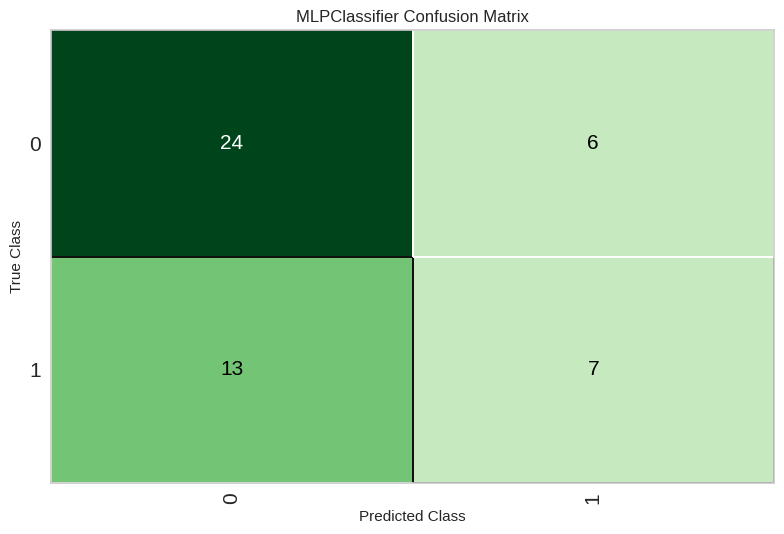

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,MLP Classifier,0.6200,0.7400,0.3500,0.5385,0.4242,0.1593,0.1675



Matriz de Confusão (holdout):
[[24  6]
 [13  7]]

Relatório de Classificação (holdout):
              precision    recall  f1-score   support

           0       0.65      0.80      0.72        30
           1       0.54      0.35      0.42        20

    accuracy                           0.62        50
   macro avg       0.59      0.57      0.57        50
weighted avg       0.60      0.62      0.60        50



In [12]:
from pycaret.classification import predict_model, plot_model
from sklearn.metrics import confusion_matrix, classification_report


melhor_modelo = best_models[0]  # melhor modelo da lista compare_models() (ele já vem ordenado).

plot_model(melhor_modelo, plot='confusion_matrix')  #matriz de confusao do melhor modelo, testado no holdout (20% que ficaram de fora)

previsoes = predict_model(melhor_modelo)  #tabela com valores reais + oq o modelo previu

print("\nMatriz de Confusão (holdout):")
print(confusion_matrix(previsoes[TARGET], previsoes['prediction_label'])) # Compara a coluna real (TARGET) com a prevista e monta a matriz de confusão

print("\nRelatório de Classificação (holdout):")
print(classification_report(previsoes[TARGET], previsoes['prediction_label'])) # Gera um resumo com Precisão, Recall e F1-Score calculados classe por classe
# — útil pra ver se o modelo erra mais numa classe específica.

## Melhor modelo: MLP Classifier

## Comparando o Cv (treino, validacao cruzada) e o holdout (dado nunca visto, 20%)
- Cv previu F1 de 0.58, no holdout caiu pra 0.42
  - teve overfitting leve
- Cv previu Acuracia de 0.705 e holdout 0.62
- não foi extremo
- O modelo generealiza, porém pior do que a validação cruzada sugeria.

<br>

---

## Matriz de Confusão - 50 pessoas

| | Previsto 0 | Previsto 1 | Total |
|:---|:----------:|:----------:|:-----:|
| **Real 0 (não comprou)** | 24 | 6 | 30 |
| **Real 1 (comprou)** | 13 | 7 | 20 |

- O modelo é bom pra achar quem não compra, mas ruim pra achar quem compra
  - Das 30 pessoas que não compraram → acertou 24
  - Das 20 pessoas que compraram → acertou só 7 (errou 13)

<br>

- real 0 = 24 acertos, 6 erros (30 pessoas que não compraram)
  - 24 acertos - disse e acertou que não comprau
  - 6 erros - modelo disse que comprou, mas não comprou
- real 1 = 13 erros, 7 acertos (20 pessoas que compraram)
  - 13 erros - disse não comprou quando na verdade comprou (perde cliente)
  - 7 acertos - disse e acertou que comprou

<br>

---

## Acuracia e F1 score
- Acuracia = % de acerto geral (62%).
  - ela sozinha pode enganar
  - O modelo Dummy Classifier (ruim) acertaria por volta de 60%
  - o MPL (esperto) arcertou só 2% a mais
- F1 score - mostra o real problema
  - F1 da classe NÃO COMPROU - 0.72
  - F1 da classe COMPROU - 0.42
  - separando as classes, mostra o que a acurácia não mostrou em uma só.
